# Healthcare Operations & Billing Intelligence Analysis

**Portfolio Project — Junior Data Analyst / Business Intelligence Analyst**

**Dataset:** `healthcare_dataset.csv`  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook

---

## Executive Summary

This project analyses **10,000 synthetic healthcare admission records** to understand patient demand, medical conditions, hospital activity, billing patterns, insurance providers, length of stay, admission timing and test results.

The analysis follows a complete analyst workflow: business framing, data inspection, data cleaning, feature engineering, GroupBy analysis, visualisation, interpretation and business recommendations.

### Headline findings

- **Asthma** has the highest admission count: **1,708 admissions**.
- **Cancer** generates the highest total billing: approximately **43.49 million billing units**.
- **Urgent** admissions have the highest average bill: approximately **25,960.83**.
- **Emergency** admissions have the longest average stay: approximately **15.61 days**.
- **Cigna** generates the highest total billing among insurers: approximately **52.34 million**.
- **October 2022** is the busiest full year-month in the dataset with **207 admissions**.
- The overall average stay is approximately **15.56 days**.
- Length of stay and billing amount have almost **no linear relationship** in this synthetic dataset (correlation approximately **-0.014**).

> **Important:** The dataset is synthetic, so the findings demonstrate analytical and BI skills and should not be interpreted as clinical evidence.

# 1. Business Problem

Healthcare organisations need to balance patient demand, bed capacity, staffing, clinical operations and financial performance. Management therefore needs a clear view of:

1. Which medical conditions drive the greatest admission volume?
2. Which conditions generate the greatest total billing?
3. Which admission types are most expensive on average?
4. How long do patients stay, and which admission type uses beds longest?
5. Are admissions changing over time?
6. Which insurance providers account for the greatest patient and billing activity?
7. How are test outcomes distributed by medical condition?
8. Which hospitals have the most activity?
9. Is longer length of stay associated with higher billing?

The purpose of this notebook is to turn raw healthcare records into operational and financial insights that could support resource planning, cost monitoring and management reporting.

# 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# 3. Load the Healthcare Dataset

The dataset is loaded with `pd.read_csv()` because it is stored as a CSV file.

The notebook looks for `healthcare_dataset.csv` in the same folder so it can be cloned and run directly from GitHub.

In [2]:
DATA_PATH = Path("healthcare_dataset.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "healthcare_dataset.csv was not found. "
        "Place the CSV in the same folder as this notebook."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 10,000
Columns: 15


# 4. Initial Data Inspection

## 4.1 `df.head()`

This gives a quick preview of the first five rows and confirms that the dataset loaded correctly.

In [3]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,"37,490.98",146,Elective,2022-12-01,Aspirin,Inconclusive
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,"47,304.06",404,Emergency,2023-06-15,Lipitor,Normal
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,"36,874.90",292,Emergency,2019-02-08,Lipitor,Normal
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,"23,303.32",480,Urgent,2020-05-03,Penicillin,Abnormal
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,"18,086.34",477,Urgent,2021-08-02,Paracetamol,Normal


## 4.2 `df.shape`

This shows the number of rows and columns.

In [4]:
df.shape

(10000, 15)

**Finding:** The dataset contains **10,000 rows and 15 original columns**.

## 4.3 `df.info()`

This checks column names, data types and non-null counts.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                10000 non-null  object 
 1   Age                 10000 non-null  int64  
 2   Gender              10000 non-null  object 
 3   Blood Type          10000 non-null  object 
 4   Medical Condition   10000 non-null  object 
 5   Date of Admission   10000 non-null  object 
 6   Doctor              10000 non-null  object 
 7   Hospital            10000 non-null  object 
 8   Insurance Provider  10000 non-null  object 
 9   Billing Amount      10000 non-null  float64
 10  Room Number         10000 non-null  int64  
 11  Admission Type      10000 non-null  object 
 12  Discharge Date      10000 non-null  object 
 13  Medication          10000 non-null  object 
 14  Test Results        10000 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 1.1+

## 4.4 `df.describe()`

This summarises numeric columns such as Age, Billing Amount and Room Number.

In [6]:
df.describe()

,Age,Billing Amount,Room Number
count,"10,000.00","10,000.00","10,000.00"
mean,51.45,"25,516.81",300.08
std,19.59,"14,067.29",115.81
min,18.00,"1,000.18",101.00
25%,35.00,"13,506.52",199.00
50%,52.00,"25,258.11",299.00
75%,68.00,"37,733.91",400.00
max,85.00,"49,995.90",500.00


## 4.5 `df.isnull().sum()`

This checks every column for missing values.

In [7]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

## 4.6 Duplicate-row check

In [8]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


## 4.7 Check categorical values

Reviewing distinct category values helps identify inconsistent capitalisation, spelling or whitespace.

In [9]:
categorical_columns = [
    "Gender", "Blood Type", "Medical Condition",
    "Insurance Provider", "Admission Type",
    "Medication", "Test Results"
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(sorted(df[col].dropna().astype(str).unique()))


Gender:
['Female', 'Male']

Blood Type:
['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']

Medical Condition:
['Arthritis', 'Asthma', 'Cancer', 'Diabetes', 'Hypertension', 'Obesity']

Insurance Provider:
['Aetna', 'Blue Cross', 'Cigna', 'Medicare', 'UnitedHealthcare']

Admission Type:
['Elective', 'Emergency', 'Urgent']

Medication:
['Aspirin', 'Ibuprofen', 'Lipitor', 'Paracetamol', 'Penicillin']

Test Results:
['Abnormal', 'Inconclusive', 'Normal']


# 5. Data Cleaning

A copy is created before cleaning so the original imported DataFrame remains unchanged.

## Cleaning decisions

### Missing values
The dataset contains **no missing values**. I therefore do **not** fill values with the mean, median, mode or `"Unknown"`, and I do not drop any rows or columns.

That is the correct choice because unnecessary imputation would alter valid data and could introduce bias.

### Duplicate rows
There are **0 exact duplicate rows**, so no records are deleted.

Removing records without evidence of duplication could understate admissions and billing totals.

### Incorrect data types
`Date of Admission` and `Discharge Date` arrive as text/object columns. They are converted to proper Pandas datetime values because date arithmetic and time-series analysis require true date fields.

`Billing Amount` is explicitly converted to numeric as a validation step so totals and averages are reliable.

### Date columns
Both date columns are converted with `pd.to_datetime(..., errors="coerce")`. Invalid dates would become `NaT`, making any issue visible in the post-cleaning validation.

### Inconsistent text formatting
Text fields are stripped of leading and trailing spaces. Selected business categories are standardised to title case so categories such as `urgent` and `Urgent` cannot accidentally be treated as different groups.

The current CSV already appears consistent, but this step makes the cleaning process robust.

### Outliers and validity
Age, billing amount and length of stay are checked for impossible values. In this dataset:

- Age ranges from **18 to 85**.
- Billing Amount ranges from approximately **1,000.18 to 49,995.90**.
- Length of stay ranges from **1 to 30 days**.
- No discharge date is earlier than its admission date.

These values are valid for this synthetic dataset, so no records are removed as outliers.

In [10]:
df_clean = df.copy()

# Remove exact duplicates only if any exist
duplicates_before = df_clean.duplicated().sum()
if duplicates_before > 0:
    df_clean = df_clean.drop_duplicates().copy()

# Convert date columns
for col in ["Date of Admission", "Discharge Date"]:
    df_clean[col] = pd.to_datetime(df_clean[col], errors="coerce")

# Confirm Billing Amount is numeric
df_clean["Billing Amount"] = pd.to_numeric(
    df_clean["Billing Amount"], errors="coerce"
)

# Remove leading/trailing whitespace from text fields
text_columns = df_clean.select_dtypes(include="object").columns
for col in text_columns:
    df_clean[col] = df_clean[col].str.strip()

# Standardise selected business categories
for col in [
    "Gender", "Medical Condition", "Insurance Provider",
    "Admission Type", "Medication", "Test Results"
]:
    df_clean[col] = df_clean[col].str.title()

print(f"Duplicates found before cleaning: {duplicates_before}")
print(f"Rows after cleaning: {len(df_clean):,}")

print("\nMissing values after conversions:")
print(df_clean.isnull().sum())

Duplicates found before cleaning: 0
Rows after cleaning: 10,000

Missing values after conversions:
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


## 5.1 Post-cleaning validation

In [11]:
print("Age range:", df_clean["Age"].min(), "to", df_clean["Age"].max())

print(
    "Billing range:",
    round(df_clean["Billing Amount"].min(), 2),
    "to",
    round(df_clean["Billing Amount"].max(), 2)
)

print(
    "Admission date range:",
    df_clean["Date of Admission"].min().date(),
    "to",
    df_clean["Date of Admission"].max().date()
)

invalid_discharge = (
    df_clean["Discharge Date"] < df_clean["Date of Admission"]
).sum()

print("Discharge dates before admission:", invalid_discharge)

Age range: 18 to 85
Billing range: 1000.18 to 49995.9
Admission date range: 2018-10-30 to 2023-10-30
Discharge dates before admission: 0


# 6. Feature Engineering

Four useful columns are created:

### `Length_of_Stay`
Calculated as `Discharge Date - Date of Admission`. This supports bed-utilisation and operational analysis.

### `Admission_Month`
Stores the admission year and month so admissions can be plotted chronologically.

### `Admission_Quarter`
Stores the calendar quarter for higher-level management reporting.

### `Age_Group`
Groups patients into age bands so demographic patterns are easier to compare than individual ages.

In [12]:
df_clean["Length_of_Stay"] = (
    df_clean["Discharge Date"] - df_clean["Date of Admission"]
).dt.days

df_clean["Admission_Month"] = (
    df_clean["Date of Admission"].dt.to_period("M")
)

df_clean["Admission_Quarter"] = (
    df_clean["Date of Admission"].dt.to_period("Q")
)

age_bins = [17, 30, 45, 60, 75, np.inf]
age_labels = ["18-30", "31-45", "46-60", "61-75", "76+"]

df_clean["Age_Group"] = pd.cut(
    df_clean["Age"],
    bins=age_bins,
    labels=age_labels
)

df_clean[
    [
        "Age", "Age_Group", "Date of Admission",
        "Admission_Month", "Admission_Quarter",
        "Discharge Date", "Length_of_Stay"
    ]
].head()

,Age,Age_Group,Date of Admission,Admission_Month,Admission_Quarter,Discharge Date,Length_of_Stay
0,81,76+,2022-11-17,2022-11,2022Q4,2022-12-01,14
1,35,31-45,2023-06-01,2023-06,2023Q2,2023-06-15,14
2,61,61-75,2019-01-09,2019-01,2019Q1,2019-02-08,30
3,49,46-60,2020-05-02,2020-05,2020Q2,2020-05-03,1
4,51,46-60,2021-07-09,2021-07,2021Q3,2021-08-02,24


## 6.1 Validate engineered features

In [13]:
print(df_clean["Length_of_Stay"].describe())

print("\nAge-group counts:")
print(df_clean["Age_Group"].value_counts().sort_index())

count   10,000.00
mean        15.56
std          8.61
min          1.00
25%          8.00
50%         16.00
75%         23.00
max         30.00
Name: Length_of_Stay, dtype: float64

Age-group counts:
Age_Group
18-30    1903
31-45    2211
46-60    2225
61-75    2215
76+      1446
Name: count, dtype: int64


# 7. GroupBy Business Analysis

## 7.1 Admissions by Medical Condition

In [14]:
admissions_by_condition = (
    df_clean.groupby("Medical Condition")
    .size()
    .sort_values(ascending=False)
    .rename("Admissions")
)

admissions_by_condition

Medical Condition
Asthma          1708
Cancer          1703
Hypertension    1688
Arthritis       1650
Obesity         1628
Diabetes        1623
Name: Admissions, dtype: int64

**Insight:** Asthma has the highest admission volume with **1,708 admissions**, narrowly ahead of Cancer (**1,703**) and Hypertension (**1,688**).

**Why it matters:** High-volume conditions can place recurring pressure on beds, clinicians, medication stock and diagnostic services.

## 7.2 Total Billing by Medical Condition

In [15]:
billing_by_condition = (
    df_clean.groupby("Medical Condition")["Billing Amount"]
    .sum()
    .sort_values(ascending=False)
)

billing_by_condition.to_frame("Total Billing")

,Total Billing
Medical Condition,
Cancer,"43,493,080.71"
Asthma,"43,412,013.78"
Hypertension,"42,534,281.35"
Diabetes,"42,295,568.48"
Obesity,"41,873,531.89"
Arthritis,"41,559,591.57"


**Insight:** Cancer generates the highest total billing at approximately **43.49 million**, followed closely by Asthma at approximately **43.41 million**.

**Why it matters:** The condition with the most admissions is not necessarily the condition with the highest financial value. Management should monitor both volume and cost.

## 7.3 Average Billing by Admission Type

In [16]:
avg_billing_by_type = (
    df_clean.groupby("Admission Type")["Billing Amount"]
    .mean()
    .sort_values(ascending=False)
)

avg_billing_by_type.to_frame("Average Billing")

,Average Billing
Admission Type,
Urgent,"25,960.83"
Elective,"25,891.83"
Emergency,"24,708.51"


**Insight:** Urgent admissions have the highest average billing at approximately **25,960.83**, followed by Elective admissions at approximately **25,891.83**.

**Why it matters:** The difference is modest, but Urgent admissions are a sensible area for deeper cost-driver analysis.

## 7.4 Average Length of Stay by Admission Type

In [17]:
avg_los_by_type = (
    df_clean.groupby("Admission Type")["Length_of_Stay"]
    .mean()
    .sort_values(ascending=False)
)

avg_los_by_type.to_frame("Average Length of Stay")

,Average Length of Stay
Admission Type,
Emergency,15.61
Elective,15.60
Urgent,15.48


**Insight:** Emergency admissions have the longest average stay at approximately **15.61 days**.

**Why it matters:** Even small differences in average stay can affect bed availability when applied across thousands of admissions.

## 7.5 Insurance Provider Analysis

In [18]:
insurance_summary = (
    df_clean.groupby("Insurance Provider")
    .agg(
        Admissions=("Name", "size"),
        Total_Billing=("Billing Amount", "sum"),
        Average_Billing=("Billing Amount", "mean")
    )
    .sort_values("Total_Billing", ascending=False)
)

insurance_summary

,Admissions,Total_Billing,Average_Billing
Insurance Provider,,,
Cigna,2040,"52,340,171.59","25,656.95"
Aetna,2025,"52,321,794.76","25,837.92"
Blue Cross,2032,"52,125,858.90","25,652.49"
Unitedhealthcare,1978,"50,250,467.70","25,404.69"
Medicare,1925,"48,129,774.83","25,002.48"


**Insight:** Cigna has the highest total billing at approximately **52.34 million**, while Aetna is very close at approximately **52.32 million**.

**Why it matters:** Payer concentration affects revenue-cycle workload, claim management and commercial relationship monitoring.

## 7.6 Hospital Performance Snapshot

In [19]:
hospital_summary = (
    df_clean.groupby("Hospital")
    .agg(
        Admissions=("Name", "size"),
        Total_Billing=("Billing Amount", "sum"),
        Average_Billing=("Billing Amount", "mean"),
        Average_LOS=("Length_of_Stay", "mean")
    )
    .sort_values(["Admissions", "Total_Billing"], ascending=False)
)

hospital_summary.head(10)

,Admissions,Total_Billing,Average_Billing,Average_LOS
Hospital,,,,
Smith PLC,19,"432,283.55","22,751.77",15.95
Smith and Sons,17,"477,638.88","28,096.40",19.88
Smith Ltd,14,"428,163.07","30,583.08",11.71
Smith Inc,14,"351,463.89","25,104.56",17.00
Johnson PLC,13,"269,777.54","20,752.12",11.92
Williams LLC,12,"327,522.47","27,293.54",16.08
Smith Group,12,"247,635.08","20,636.26",18.83
Williams Inc,12,"245,434.30","20,452.86",14.75
Thomas Group,11,"327,045.37","29,731.40",16.91


**Insight:** `Smith PLC` has the highest admission count with **19 records**. However, hospital names are very fragmented, with thousands of unique values.

**Why it matters:** In a real BI project, hospital master-data standardisation would be essential before making performance rankings.

## 7.7 Test Results by Medical Condition

In [20]:
test_results_by_condition = pd.crosstab(
    df_clean["Medical Condition"],
    df_clean["Test Results"]
)

test_results_by_condition

Test Results,Abnormal,Inconclusive,Normal
Medical Condition,,,
Arthritis,555,553,542
Asthma,623,551,534
Cancer,577,556,570
Diabetes,537,542,544
Hypertension,602,554,532
Obesity,562,521,545


**Insight:** Abnormal results are the largest overall test-result category with **3,456 records**. Asthma has **623 abnormal results**, the highest abnormal count among the medical conditions.

**Why it matters:** Test-result mix can help operations teams estimate follow-up workload. Because the dataset is synthetic, this should not be interpreted as clinical risk.

## 7.8 Monthly Admissions

In [21]:
monthly_admissions = (
    df_clean.groupby("Admission_Month")
    .size()
    .rename("Admissions")
    .sort_index()
)

print("Highest-volume months:")
print(monthly_admissions.sort_values(ascending=False).head())

monthly_admissions.head()

Highest-volume months:
Admission_Month
2022-10    207
2020-05    195
2023-08    186
2021-11    183
2021-08    182
Freq: M, Name: Admissions, dtype: int64


Admission_Month
2018-10      8
2018-11    145
2018-12    150
2019-01    178
2019-02    138
Freq: M, Name: Admissions, dtype: int64

**Insight:** **October 2022** is the busiest full year-month with **207 admissions**, followed by May 2020 with **195**.

**Why it matters:** Peak periods can guide workforce and capacity planning. The dataset starts and ends part-way through October in 2018 and 2023, so those edge months are partial and should be interpreted carefully.

# 8. Required Visualisations

For each chart I explain:
- why the chart type was selected,
- what it shows,
- the main insight,
- why the insight matters to the healthcare business.

## Chart 1 — Admissions by Medical Condition

**Why this chart:** A horizontal bar chart is ideal for comparing counts across a small number of categories.

**What it shows:** Total admissions for each medical condition.

**Insight:** Asthma has the highest volume with 1,708 admissions, while Diabetes has the lowest of the six conditions with 1,623. The distribution is relatively balanced.

**Why it matters:** Admission volume influences staffing, bed demand, medication inventory and diagnostic workload.

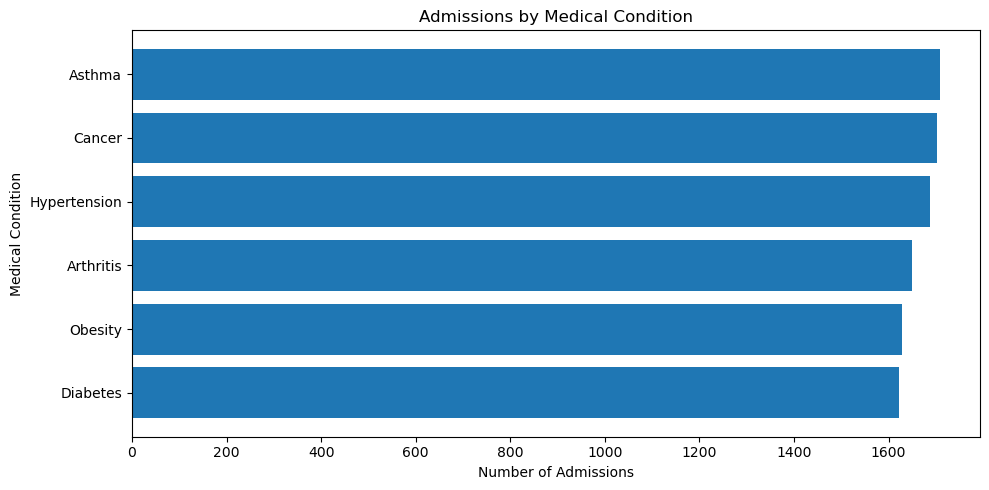

In [33]:
plt.figure(figsize=(10, 5))
plt.barh(
    admissions_by_condition.index[::-1],
    admissions_by_condition.values[::-1]
)
plt.title("Admissions by Medical Condition")
plt.xlabel("Number of Admissions")
plt.ylabel("Medical Condition")
plt.tight_layout()
plt.show()

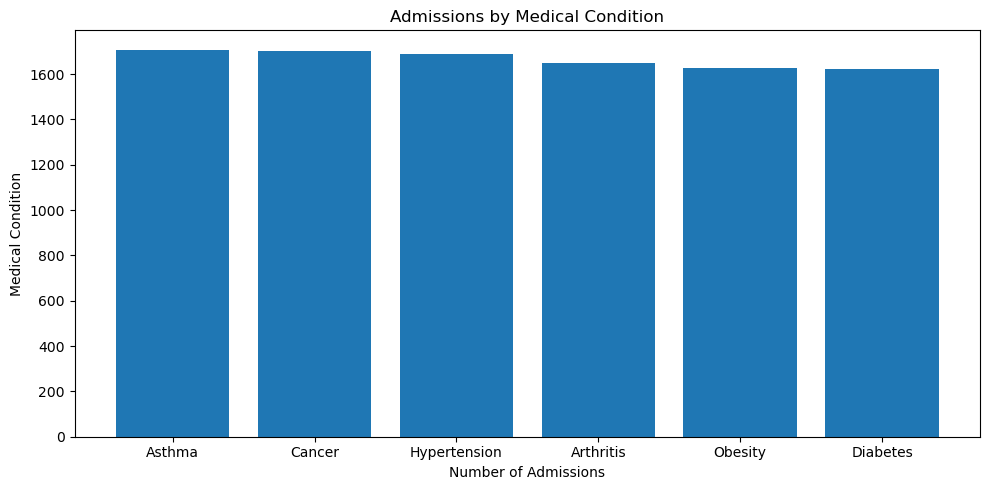

In [34]:
plt.figure(figsize=(10, 5))
plt.bar(
    admissions_by_condition.index,
    admissions_by_condition.values
)
plt.title("Admissions by Medical Condition")
plt.xlabel("Number of Admissions")
plt.ylabel("Medical Condition")
plt.tight_layout()
plt.show()

## Chart 2 — Total Billing by Medical Condition

**Why this chart:** A horizontal bar chart makes total billing differences easy to compare while keeping condition labels readable.

**What it shows:** Total billing generated by each medical condition.

**Insight:** Cancer has the highest total billing at about 43.49 million, with Asthma very close behind at 43.41 million.

**Why it matters:** High-volume and high-billing conditions are not always identical, so management should monitor both operational and financial KPIs.

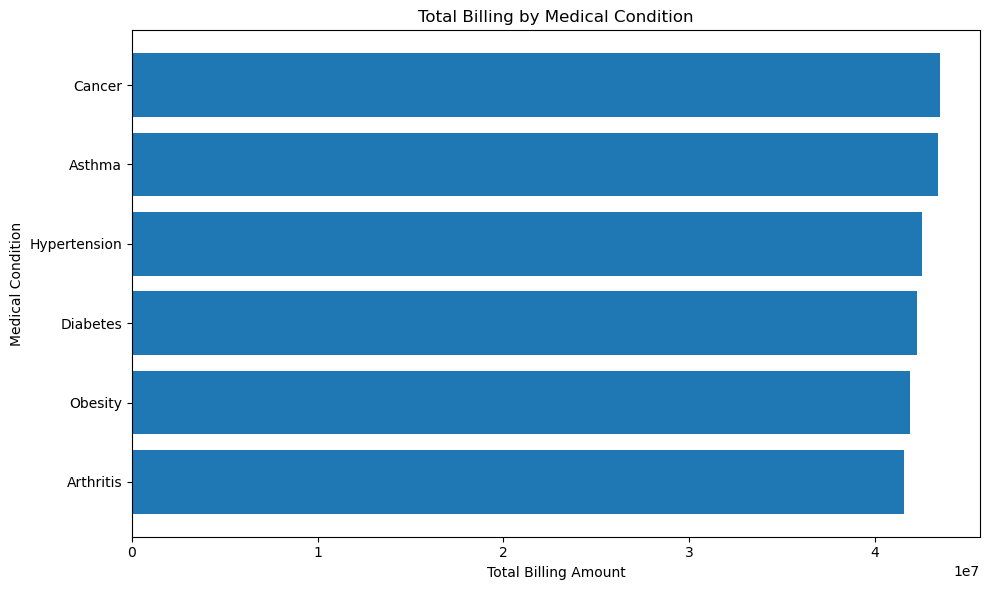

In [23]:
plt.figure(figsize=(10, 6))
plt.barh(
    billing_by_condition.index[::-1],
    billing_by_condition.values[::-1]
)
plt.title("Total Billing by Medical Condition")
plt.xlabel("Total Billing Amount")
plt.ylabel("Medical Condition")
plt.tight_layout()
plt.show()

## Chart 3 — Average Billing by Admission Type

**Why this chart:** A bar chart gives a direct comparison of mean billing across the three admission categories.

**What it shows:** Average Billing Amount for Urgent, Elective and Emergency admissions.

**Insight:** Urgent admissions have the highest average bill at about 25,960.83.

**Why it matters:** Average cost by admission pathway can help managers identify areas for service-cost and utilisation review.

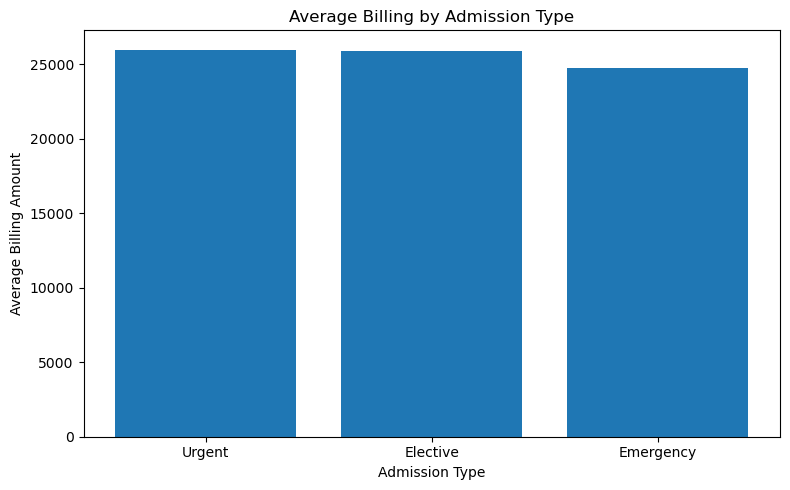

In [24]:
plt.figure(figsize=(8, 5))
plt.bar(avg_billing_by_type.index, avg_billing_by_type.values)
plt.title("Average Billing by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Average Billing Amount")
plt.tight_layout()
plt.show()

## Chart 4 — Length of Stay Distribution

**Why this chart:** A histogram is designed for numeric distributions and shows how frequently different stay lengths occur.

**What it shows:** The frequency of hospital stays from 1 to 30 days.

**Insight:** Length of stay is broadly distributed across the range. The average is about 15.56 days and the median is 16 days.

**Why it matters:** Length of stay is a major bed-utilisation metric and helps managers think about patient turnover and capacity.

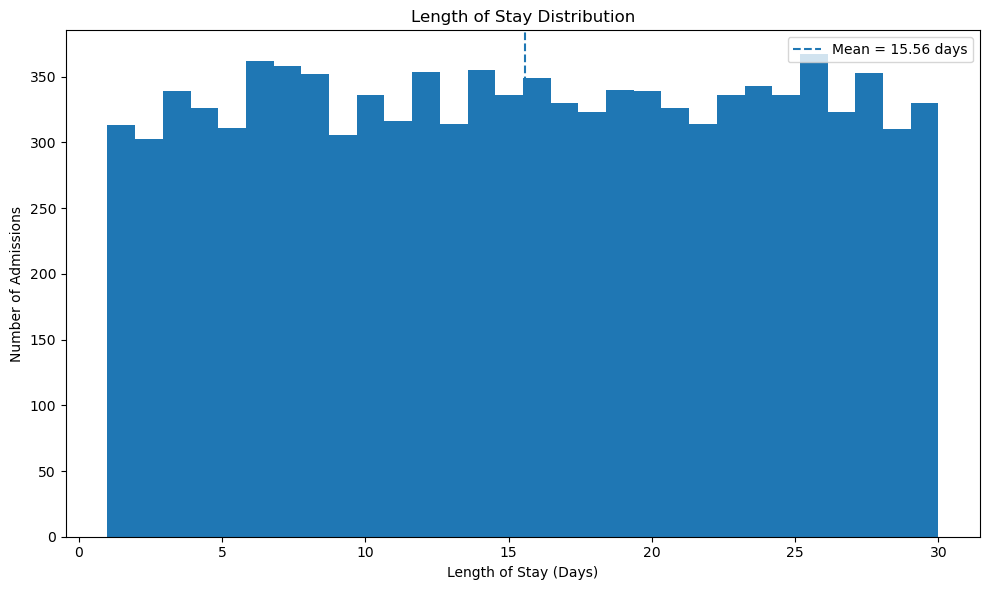

In [25]:
plt.figure(figsize=(10, 6))
plt.hist(df_clean["Length_of_Stay"], bins=30)
plt.axvline(
    df_clean["Length_of_Stay"].mean(),
    linestyle="--",
    label=f'Mean = {df_clean["Length_of_Stay"].mean():.2f} days'
)
plt.title("Length of Stay Distribution")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Number of Admissions")
plt.legend()
plt.tight_layout()
plt.show()

## Chart 5 — Monthly Admission Trend

**Why this chart:** A line chart is appropriate for chronological data and makes changes, peaks and dips over time easy to see.

**What it shows:** Monthly admission counts from late 2018 to late 2023.

**Insight:** Admissions fluctuate month to month without a strong sustained upward or downward trend. October 2022 is the highest month with 207 admissions.

**Why it matters:** Time trends can support staffing, scheduling, bed planning and future forecasting.

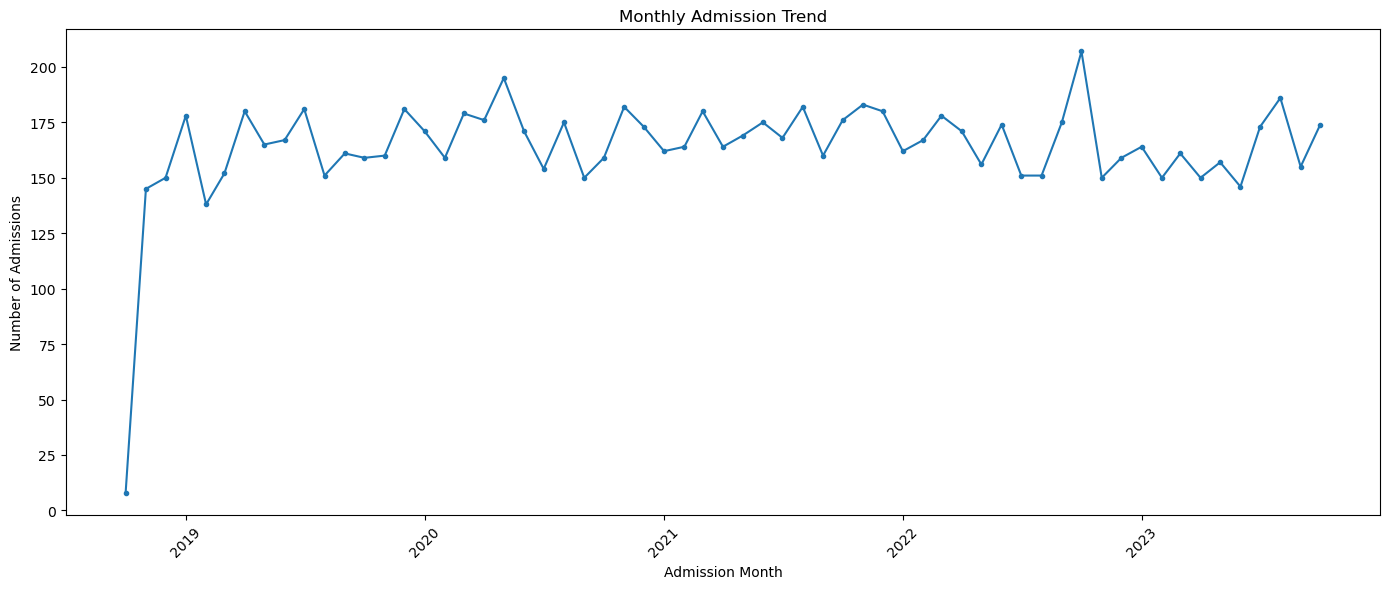

In [26]:
monthly_plot = monthly_admissions.copy()
monthly_plot.index = monthly_plot.index.to_timestamp()

plt.figure(figsize=(14, 6))
plt.plot(
    monthly_plot.index,
    monthly_plot.values,
    marker="o",
    markersize=3
)
plt.title("Monthly Admission Trend")
plt.xlabel("Admission Month")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Chart 6 — Test Results by Medical Condition

**Why this chart:** A heatmap is useful for comparing two categorical dimensions at the same time and quickly identifying larger and smaller counts.

**What it shows:** Counts of Abnormal, Inconclusive and Normal test results across each medical condition.

**Insight:** Abnormal results are the largest overall category, and Asthma has the highest abnormal-result count at 623.

**Why it matters:** Test-result distribution can support workload planning for diagnostics and patient follow-up.

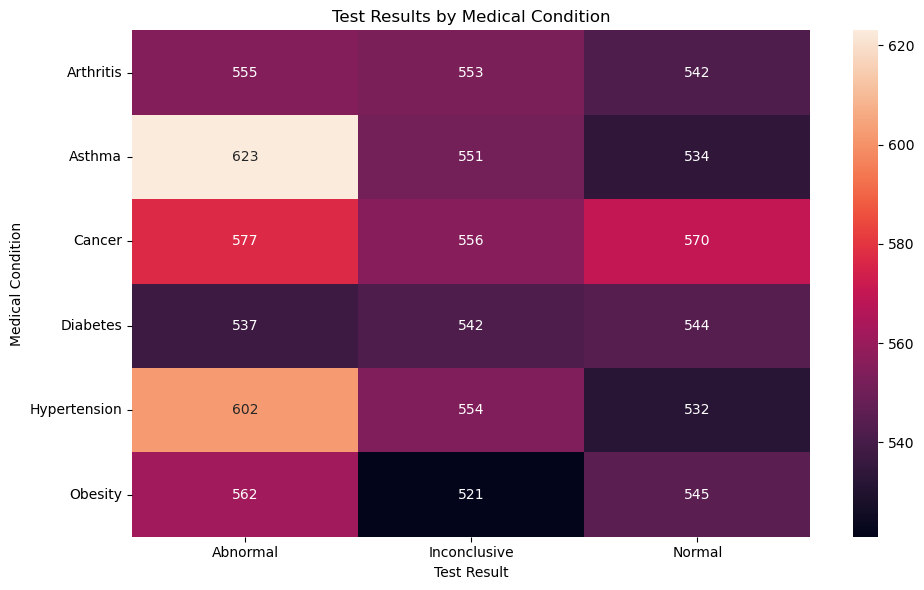

In [27]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    test_results_by_condition,
    annot=True,
    fmt="d"
)
plt.title("Test Results by Medical Condition")
plt.xlabel("Test Result")
plt.ylabel("Medical Condition")
plt.tight_layout()
plt.show()

# 9. Additional Visualisations

## Chart 7 — Total Billing by Insurance Provider

**Why this chart:** A bar chart supports quick comparison of billing concentration across payers.

**What it shows:** Total Billing Amount associated with each insurance provider.

**Insight:** Cigna and Aetna have the largest billing totals, both above 52 million.

**Why it matters:** Payer concentration affects claims processing and revenue-cycle management.

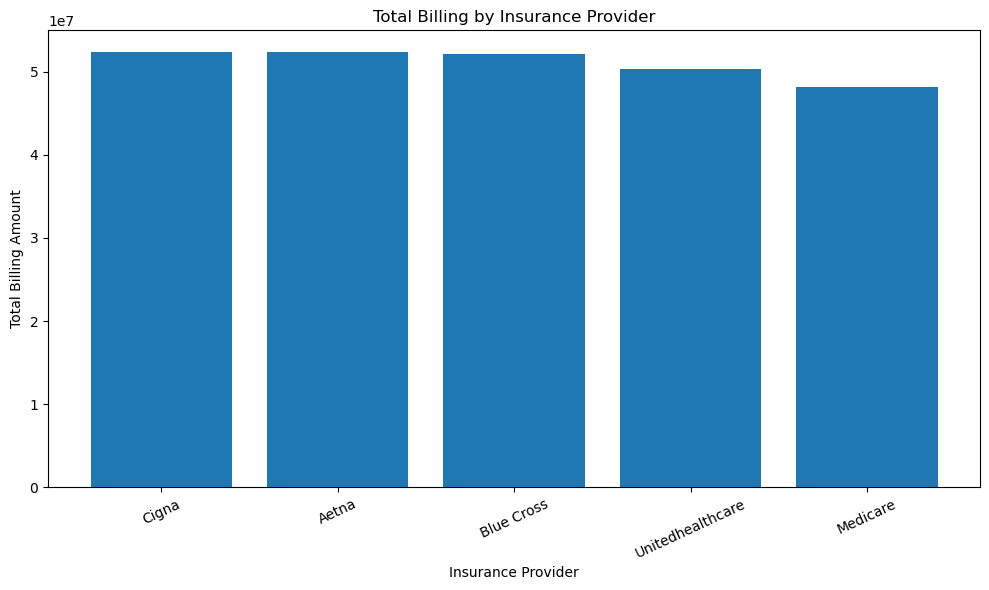

In [28]:
insurance_billing = (
    df_clean.groupby("Insurance Provider")["Billing Amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(insurance_billing.index, insurance_billing.values)
plt.title("Total Billing by Insurance Provider")
plt.xlabel("Insurance Provider")
plt.ylabel("Total Billing Amount")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Chart 8 — Average Length of Stay by Admission Type

**Why this chart:** A bar chart provides a simple comparison of the three admission pathways.

**What it shows:** Mean length of stay by admission type.

**Insight:** Emergency admissions stay the longest on average at approximately 15.61 days, although differences are small.

**Why it matters:** Admission pathways that occupy beds longer can influence capacity planning.

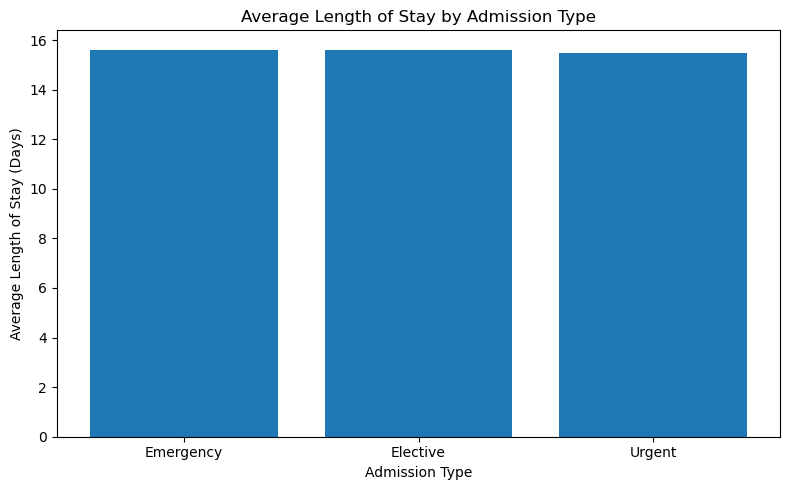

In [29]:
plt.figure(figsize=(8, 5))
plt.bar(avg_los_by_type.index, avg_los_by_type.values)
plt.title("Average Length of Stay by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Average Length of Stay (Days)")
plt.tight_layout()
plt.show()

## Chart 9 — Admissions by Age Group

**Why this chart:** A bar chart clearly compares the engineered age segments.

**What it shows:** Admission volume by age band.

**Insight:** Grouping age simplifies demographic comparison and makes population patterns easier to communicate.

**Why it matters:** Age segmentation can support service planning, patient communication and demand forecasting.

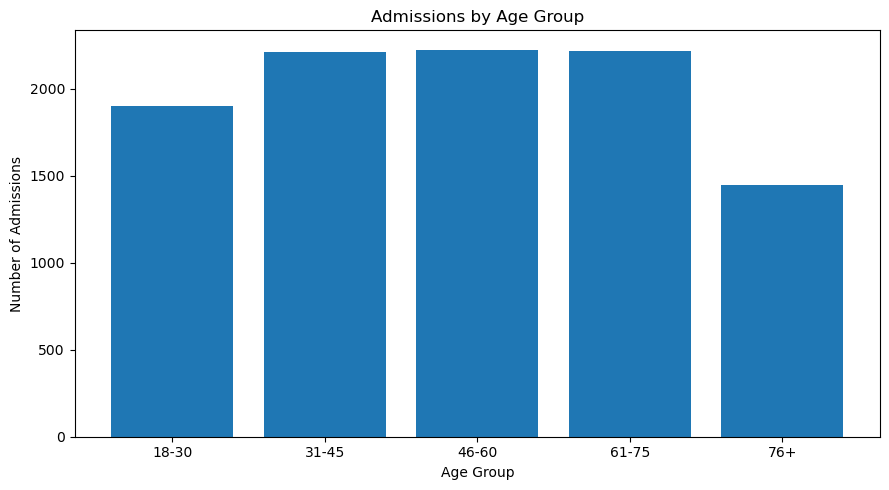

In [30]:
age_group_counts = (
    df_clean["Age_Group"]
    .value_counts()
    .reindex(["18-30", "31-45", "46-60", "61-75", "76+"])
)

plt.figure(figsize=(9, 5))
plt.bar(age_group_counts.index.astype(str), age_group_counts.values)
plt.title("Admissions by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Admissions")
plt.tight_layout()
plt.show()

## Chart 10 — Length of Stay vs Billing Amount

**Why this chart:** A scatter plot is appropriate when examining the relationship between two numeric variables. Seaborn is used here to also segment the points by admission type.

**What it shows:** Billing Amount against Length of Stay for each admission.

**Insight:** The correlation is approximately -0.014, indicating almost no linear relationship between length of stay and billing in this synthetic dataset.

**Why it matters:** Management should not assume that longer stays automatically create larger bills. Other variables may be more important billing drivers.

Correlation between Length of Stay and Billing Amount: -0.014


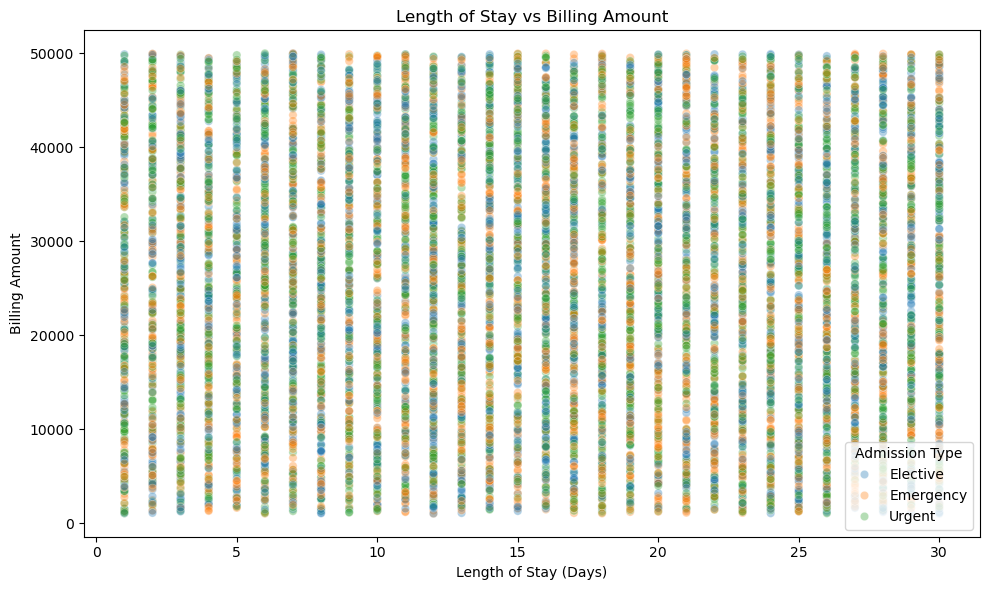

In [31]:
los_billing_corr = df_clean["Length_of_Stay"].corr(
    df_clean["Billing Amount"]
)

print(
    "Correlation between Length of Stay and Billing Amount:",
    round(los_billing_corr, 3)
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean,
    x="Length_of_Stay",
    y="Billing Amount",
    hue="Admission Type",
    alpha=0.35
)
plt.title("Length of Stay vs Billing Amount")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Billing Amount")
plt.tight_layout()
plt.show()

# 10. KPI Summary

In [32]:
kpi_summary = pd.Series({
    "Total Admissions": len(df_clean),
    "Total Billing": df_clean["Billing Amount"].sum(),
    "Average Billing per Admission": df_clean["Billing Amount"].mean(),
    "Average Length of Stay": df_clean["Length_of_Stay"].mean(),
    "Median Length of Stay": df_clean["Length_of_Stay"].median(),
    "Highest-Volume Condition": admissions_by_condition.index[0],
    "Highest-Billing Condition": billing_by_condition.index[0],
    "Highest-Billing Insurer": insurance_summary.index[0]
})

kpi_summary

Total Admissions                         10000
Total Billing                   255,168,067.78
Average Billing per Admission        25,516.81
Average Length of Stay                   15.56
Median Length of Stay                    16.00
Highest-Volume Condition                Asthma
Highest-Billing Condition               Cancer
Highest-Billing Insurer                  Cigna
dtype: object

# 11. Main Business Insights

### 1. Asthma is the highest-volume condition
Asthma accounts for **1,708 admissions**, narrowly above Cancer and Hypertension. The six conditions are relatively balanced, so no single service line completely dominates demand.

### 2. Cancer has the highest total billing
Cancer generates approximately **43.49 million** in total billing, with Asthma close behind. Admission volume and financial value should therefore be tracked separately.

### 3. Urgent admissions have the highest average bill
Urgent admissions average approximately **25,960.83**. The difference from Elective admissions is small, but it is still worth investigating the underlying service mix.

### 4. Emergency admissions stay slightly longer
Emergency admissions average approximately **15.61 days**, compared with about 15.60 for Elective and 15.48 for Urgent.

### 5. Cigna has the largest insurer billing total
Cigna accounts for approximately **52.34 million** in total billing, slightly ahead of Aetna.

### 6. Monthly admissions fluctuate
The largest full monthly count is **207 admissions in October 2022**. The time series does not show a strong sustained trend.

### 7. Abnormal test results are the largest outcome category
There are **3,456 Abnormal**, **3,277 Inconclusive** and **3,267 Normal** test results. Asthma has the largest abnormal count at **623**.

### 8. Length of stay does not explain billing on its own
The correlation between Length of Stay and Billing Amount is about **-0.014**, effectively zero.

### 9. Hospital names are highly fragmented
The most frequent hospital has only 19 records. In a real organisation, this would trigger a hospital master-data quality review before meaningful benchmarking.

# 12. Business Recommendations

## Recommendation 1 — Separate operational and financial scorecards
Track admission volume, total billing, average billing and average length of stay separately by medical condition. Asthma leads volume while Cancer leads billing, so one KPI alone could create misleading priorities.

## Recommendation 2 — Review cost drivers for Urgent admissions
Urgent admissions have the highest average bill. Break this down by medical condition, medication, insurer and hospital to understand what drives the difference.

## Recommendation 3 — Monitor length of stay for capacity planning
Emergency admissions have the longest average stay. Management dashboards should track average stay, median stay and long-stay cases by admission type.

## Recommendation 4 — Strengthen payer reporting
Cigna and Aetna have the highest total billing. Revenue-cycle teams should monitor claim volume, billing value and, if future data becomes available, rejection rates and payment delays by insurer.

## Recommendation 5 — Monitor monthly demand
Use monthly admission trends to identify recurring peaks and align staffing and bed capacity with expected demand.

## Recommendation 6 — Track test-result follow-up workload
Abnormal and inconclusive results together account for more than two-thirds of records. Where operational data is available, monitor follow-up queues and turnaround times.

## Recommendation 7 — Improve hospital master data before benchmarking
Create standard hospital IDs and naming rules before comparing hospitals. Fragmented names can produce misleading rankings.

## Recommendation 8 — Expand billing-driver analysis
Because length of stay has almost no relationship with billing in this dataset, future analysis should test medical condition, admission type, insurer, medication, age and hospital together.

# 13. Limitations

- The dataset is **synthetic**, so findings demonstrate analytical technique rather than real clinical or financial performance.
- There is no diagnosis severity, procedure, claims-status, staffing or bed-capacity field.
- Hospital names are highly fragmented, limiting meaningful hospital-level benchmarking.
- Billing Amount does not show actual paid amount, outstanding balance or rejected claims.
- The first and last calendar months are partial periods.
- Correlation does not prove causation.

A professional analyst should communicate these limitations so stakeholders understand what the data can and cannot support.

# 14. Conclusion

This project demonstrates an end-to-end healthcare BI workflow using Pandas, Matplotlib and Seaborn.

The analysis identifies patient-demand patterns, high-billing conditions, admission-type cost differences, payer concentration, length-of-stay behaviour, monthly trends and test-result patterns, then translates those findings into business recommendations.

The central lesson is that healthcare performance should not be judged using a single metric. **Volume, billing, length of stay, payer mix and test results provide different views of the operation and are most useful when considered together.**